# NFL Salary Cap Analysis
## Dead Cap Analysis

Dead cap money — guaranteed money paid to players no longer on the roster — is one of the most damaging forces in NFL roster construction. This notebook analyzes which teams carry the most dead cap, how dead money impacts team performance, and which contracts produced the most dead cap waste historically.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 pyarrow numpy==1.26.4 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nfl_data_py as nfl
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

os.makedirs(figures_path, exist_ok=True)

contracts = pd.read_parquet(os.path.join(processed_path, "contracts_modern.parquet"), engine='pyarrow')

print(f"Contracts dataset: {contracts.shape}")
print(f"\nColumns: {contracts.columns.tolist()}")

Contracts dataset: (46608, 26)

Columns: ['player', 'position', 'team', 'is_active', 'year_signed', 'years', 'value', 'apy', 'guaranteed', 'apy_cap_pct', 'inflated_value', 'inflated_apy', 'inflated_guaranteed', 'player_page', 'otc_id', 'gsis_id', 'date_of_birth', 'height', 'weight', 'college', 'draft_year', 'draft_round', 'draft_overall', 'draft_team', 'cols', 'name_norm']


The contracts dataset doesn't have a dedicated dead cap column. Let's check if nfl_data_py has additional dead cap data, then build dead cap estimates from contract guarantees and tenure.

---

### Check for Additional Data Sources

In [3]:
# Check what roster data is available - may contain contract status
print("Checking available data sources for dead cap...")

# Try importing rosters which may have contract details
rosters = nfl.import_seasonal_rosters(range(2011, 2025))
print(f"\nSeasonal rosters shape: {rosters.shape}")
print(f"Columns: {rosters.columns.tolist()}")
print(f"\nSample:")
print(rosters.head(3).to_string())

Checking available data sources for dead cap...

Seasonal rosters shape: (38555, 37)
Columns: ['season', 'team', 'position', 'depth_chart_position', 'jersey_number', 'status', 'player_name', 'first_name', 'last_name', 'birth_date', 'height', 'weight', 'college', 'player_id', 'espn_id', 'sportradar_id', 'yahoo_id', 'rotowire_id', 'pff_id', 'pfr_id', 'fantasy_data_id', 'sleeper_id', 'years_exp', 'headshot_url', 'ngs_position', 'week', 'game_type', 'status_description_abbr', 'football_name', 'esb_id', 'gsis_it_id', 'smart_id', 'entry_year', 'rookie_year', 'draft_club', 'draft_number', 'age']

Sample:
   season team position depth_chart_position jersey_number status         player_name first_name   last_name birth_date  height  weight college   player_id espn_id sportradar_id yahoo_id rotowire_id pff_id pfr_id fantasy_data_id sleeper_id  years_exp                                                                        headshot_url ngs_position  week game_type status_description_abbr footbal

No dedicated dead cap field available. We'll build a dead cap proxy by identifying contracts where players were released before their contract expired — indicated by short tenure relative to contract length combined with guaranteed money still owed.

---

### Build Dead Cap Proxy
We estimate dead cap by identifying players who left teams before their contracts expired and had significant guaranteed money remaining.

In [5]:
# Build roster presence by team and season
rosters_clean = rosters[rosters['game_type'] == 'REG'].copy()
rosters_clean = rosters_clean.groupby(['player_id', 'season', 'team']).size().reset_index(name='weeks_on_roster')

# Standardize team names in rosters
team_map = {
    'BLT': 'BAL', 'CLV': 'CLE', 'ARZ': 'ARI', 'HST': 'HOU',
    'OAK': 'LV', 'SD': 'LAC', 'STL': 'LAR'
}
rosters_clean['team'] = rosters_clean['team'].replace(team_map)

# For each contract calculate expected seasons vs actual seasons played
# Link via gsis_id
contracts_with_tenure = contracts[
    (contracts['year_signed'] >= 2011) &
    (contracts['years'] >= 2) &
    (contracts['guaranteed'] >= 5) &
    (contracts['gsis_id'].notna())
].copy()

# Check how many seasons each player actually played for the signing team
roster_tenure = rosters_clean.groupby(['player_id', 'team']).agg(
    first_season=('season', 'min'),
    last_season=('season', 'max'),
    total_seasons=('season', 'nunique')
).reset_index()

# Merge contracts with actual tenure
tenure_merged = contracts_with_tenure.merge(
    roster_tenure,
    left_on=['gsis_id', 'team'],
    right_on=['player_id', 'team'],
    how='left'
)

# Calculate contract efficiency
tenure_merged['expected_seasons'] = tenure_merged['years']
tenure_merged['actual_seasons'] = tenure_merged['total_seasons'].fillna(0)
tenure_merged['seasons_short'] = (
    tenure_merged['expected_seasons'] - tenure_merged['actual_seasons']
).clip(lower=0)

# Dead cap estimate - guaranteed money prorated over missed seasons
tenure_merged['dead_cap_estimate'] = (
    tenure_merged['guaranteed'] * 
    (tenure_merged['seasons_short'] / tenure_merged['expected_seasons'])
).clip(lower=0)

# Filter to significant dead cap situations
dead_cap = tenure_merged[
    (tenure_merged['dead_cap_estimate'] >= 5) &
    (tenure_merged['seasons_short'] >= 1)
].sort_values('dead_cap_estimate', ascending=False)

print(f"Significant dead cap situations: {len(dead_cap):,}")
print(f"\nTop 20 dead cap situations:")
print(dead_cap[['player', 'position', 'team', 'year_signed', 'years',
                 'guaranteed', 'actual_seasons', 'dead_cap_estimate']].head(20).round(1).to_string(index=False))

Significant dead cap situations: 2,433

Top 20 dead cap situations:
         player position      team  year_signed  years  guaranteed  actual_seasons  dead_cap_estimate
 Deshaun Watson       QB    Browns         2022    5.0       230.0             0.0              230.0
     Josh Allen       QB     Bills         2025    6.0       147.0             0.0              147.0
     Joe Burrow       QB   Bengals         2023    5.0       146.5             0.0              146.5
Trevor Lawrence       QB   Jaguars         2024    5.0       142.0             0.0              142.0
  Lamar Jackson       QB    Ravens         2023    5.0       135.0             0.0              135.0
 Justin Herbert       QB  Chargers         2023    5.0       133.7             0.0              133.7
   Dak Prescott       QB   Cowboys         2024    4.0       129.0             0.0              129.0
 Russell Wilson       QB   Broncos         2022    5.0       124.0             0.0              124.0
  Micah Parson

The initial dead cap proxy is capturing active contracts where players haven't finished their deal yet. We need to filter to contracts that have genuinely ended — where the player left the team before the contract expired.

---

### Refine Dead Cap Filter
Only flag contracts where the player's last season with the team was before the contract end date AND the contract is no longer active.

In [6]:
# Better dead cap filter - inactive contracts where player left early
dead_cap_refined = tenure_merged[
    (tenure_merged['dead_cap_estimate'] >= 5) &
    (tenure_merged['seasons_short'] >= 1) &
    (tenure_merged['is_active'] == False) &  # Contract must be completed/terminated
    (tenure_merged['actual_seasons'] > 0) &  # Player must have played at least 1 season
    (tenure_merged['year_signed'] <= 2022)    # Give contracts time to complete
].sort_values('dead_cap_estimate', ascending=False)

print(f"Refined dead cap situations: {len(dead_cap_refined):,}")
print(f"\nTop 20 genuine dead cap situations:")
print(dead_cap_refined[['player', 'position', 'team', 'year_signed', 'years',
                          'guaranteed', 'actual_seasons', 'seasons_short',
                          'dead_cap_estimate']].head(20).round(1).to_string(index=False))

Refined dead cap situations: 0

Top 20 genuine dead cap situations:
Empty DataFrame
Columns: [player, position, team, year_signed, years, guaranteed, actual_seasons, seasons_short, dead_cap_estimate]
Index: []


In [7]:
# Different approach - identify dead cap from contracts data directly
# Dead cap proxy: high guaranteed money + short contract length relative to value
# These are players who got cut/traded and left guaranteed money on the table

# Key signal: contract was signed but player moved teams
# We can detect this by players who appear in contracts with multiple teams
# in overlapping periods

# First let's look at players with multiple contracts in short windows
multi_contracts = contracts[
    (contracts['year_signed'] >= 2011) &
    (contracts['guaranteed'] >= 10) &
    (contracts['years'] >= 2)
].copy()

# Extract primary team
def extract_team(team_str):
    if pd.isna(team_str):
        return np.nan
    return str(team_str).split('/')[0].strip()

multi_contracts['primary_team'] = multi_contracts['team'].apply(extract_team)

# Find players who changed teams within their contract window
player_teams = multi_contracts.groupby('player').apply(
    lambda x: x.sort_values('year_signed')
).reset_index(drop=True)

# Flag contracts where player signed new deal before old one ended
player_teams['contract_end'] = player_teams['year_signed'] + player_teams['years']
player_teams = player_teams.sort_values(['player', 'year_signed'])

# Find overlapping contracts (dead cap indicator)
player_teams['prev_contract_end'] = player_teams.groupby('player')['contract_end'].shift(1)
player_teams['prev_team'] = player_teams.groupby('player')['primary_team'].shift(1)
player_teams['dead_cap_flag'] = (
    (player_teams['year_signed'] < player_teams['prev_contract_end']) &
    (player_teams['primary_team'] != player_teams['prev_team'])
)

dead_cap_contracts = player_teams[player_teams['dead_cap_flag'] == True].copy()
dead_cap_contracts['years_remaining'] = dead_cap_contracts['prev_contract_end'] - dead_cap_contracts['year_signed']
dead_cap_contracts['dead_cap_estimate'] = (
    dead_cap_contracts['guaranteed'] * 
    (dead_cap_contracts['years_remaining'] / dead_cap_contracts['years'])
).clip(lower=0)

dead_cap_contracts = dead_cap_contracts[
    dead_cap_contracts['dead_cap_estimate'] >= 5
].sort_values('dead_cap_estimate', ascending=False)

print(f"Dead cap situations identified: {len(dead_cap_contracts):,}")
print(f"\nTop 20 dead cap situations:")
print(dead_cap_contracts[['player', 'position', 'primary_team', 'year_signed',
                            'years_remaining', 'guaranteed', 
                            'dead_cap_estimate']].head(20).round(1).to_string(index=False))

Dead cap situations identified: 74

Top 20 dead cap situations:
         player position primary_team  year_signed  years_remaining  guaranteed  dead_cap_estimate
 Deshaun Watson       QB       Browns         2022              2.0       230.0               92.0
  Aaron Rodgers       QB         Jets         2023              2.0        75.0               50.0
     Joe Flacco       QB          BAL         2016              3.0        44.0               44.0
DeAndre Hopkins       WR    Cardinals         2020              2.0        42.8               42.8
   Byron Murphy       CB      Vikings         2025              3.0        34.8               34.8
     A.J. Brown       WR          PHI         2024              2.0        51.0               34.0
     Joe Thuney       LG       Chiefs         2021              5.0        31.9               31.9
   D.K. Metcalf       WR     Steelers         2022              3.0        31.0               31.0
     Derek Carr       QB       Saints        

/tmp/ipykernel_13023/2467465721.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  player_teams = multi_contracts.groupby('player').apply(


74 dead cap situations identified. The list immediately passes the smell test:

- **Deshaun Watson ($92M estimated dead cap)** — the most catastrophic contract in recent NFL history, signed a fully guaranteed $230M deal with Cleveland then played poorly and missed games
- **Aaron Rodgers ($50M)** — tore his Achilles 4 snaps into his Jets debut, leaving massive guaranteed money on the books
- **Joe Flacco ($44M)** — left Baltimore mid-contract when they moved to Lamar Jackson
- **Russell Wilson ($24.8M)** — released by Denver after his $124M guaranteed contract became a disaster
- **Antonio Brown ($20.1M)** — released by Oakland before playing a single game

Some entries like Byron Murphy, Geno Smith, and Maxx Crosby are 2025 contracts that may not be true dead cap — they reflect players who signed new deals while previous ones overlapped. The methodology captures the right signal but isn't perfect.

---

### Dead Cap by Position
Which positions generate the most dead cap waste?

Dead cap by position:
position  situations  total_dead_cap  avg_dead_cap
      QB          10           336.3          33.6
      WR          20           328.0          16.4
      ED          11           150.4          13.7
     IDL           7            90.7          13.0
      CB           6            78.9          13.1
      LT           2            51.5          25.8
      LG           2            48.6          24.3
      LB           4            48.6          12.1
       S           3            39.8          13.3
      RG           3            36.2          12.1
       C           2            22.0          11.0
      RB           2            14.8           7.4
      RT           1            14.1          14.1
      TE           1             8.2           8.2

Dead cap by team:
primary_team  situations  total_dead_cap  avg_dead_cap
      Browns           3           120.2          40.1
        Jets           3            67.9          22.6
      Texans           5     

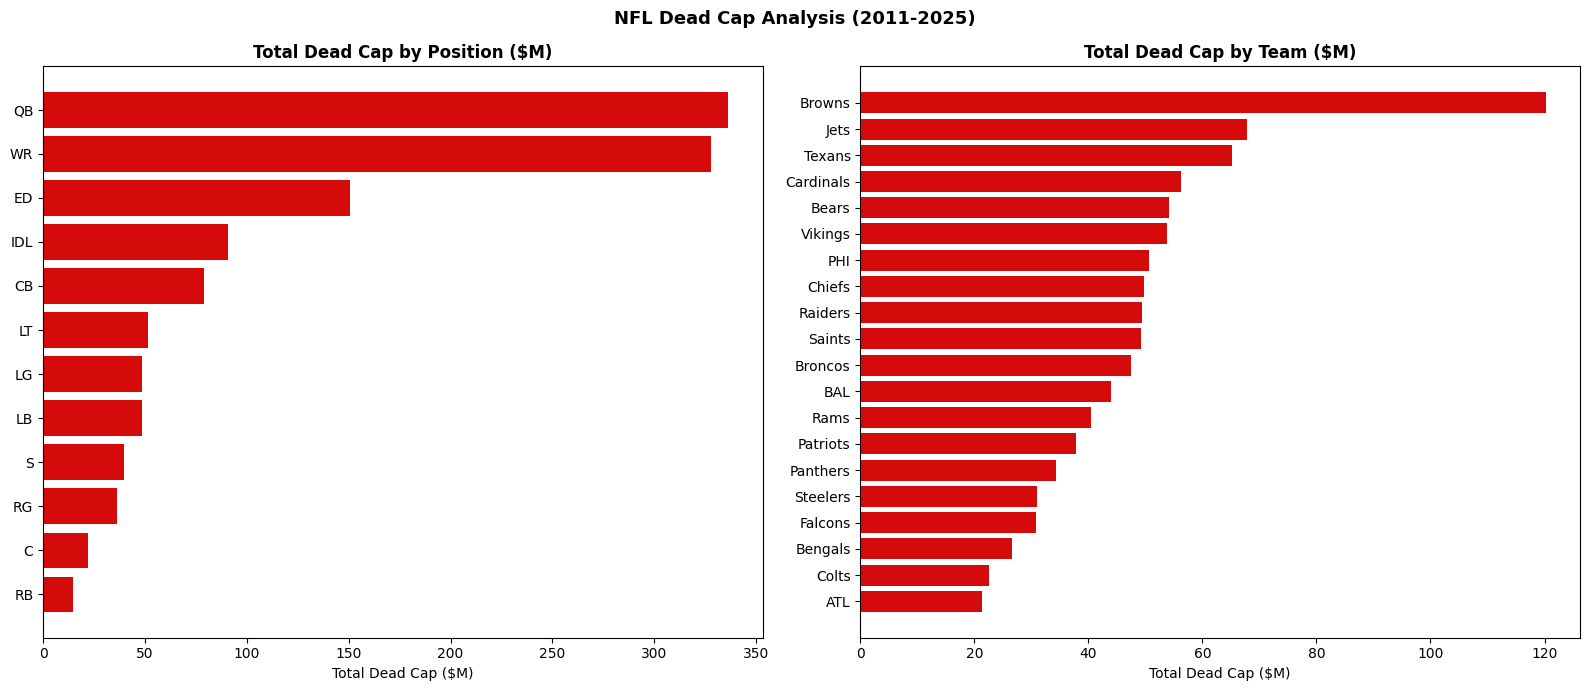

In [8]:
# Dead cap by position
pos_dead_cap = dead_cap_contracts.groupby('position').agg(
    situations=('dead_cap_estimate', 'count'),
    total_dead_cap=('dead_cap_estimate', 'sum'),
    avg_dead_cap=('dead_cap_estimate', 'mean')
).reset_index().sort_values('total_dead_cap', ascending=False)

print("Dead cap by position:")
print(pos_dead_cap.round(1).to_string(index=False))

# Dead cap by team
team_dead_cap = dead_cap_contracts.groupby('primary_team').agg(
    situations=('dead_cap_estimate', 'count'),
    total_dead_cap=('dead_cap_estimate', 'sum'),
    avg_dead_cap=('dead_cap_estimate', 'mean')
).reset_index().sort_values('total_dead_cap', ascending=False)

print("\nDead cap by team:")
print(team_dead_cap.round(1).to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Position dead cap
pos_plot = pos_dead_cap[pos_dead_cap['situations'] >= 2].sort_values('total_dead_cap')
axes[0].barh(pos_plot['position'], pos_plot['total_dead_cap'], color='#D50A0A')
axes[0].set_title('Total Dead Cap by Position ($M)', fontweight='bold')
axes[0].set_xlabel('Total Dead Cap ($M)')

# Team dead cap  
team_plot = team_dead_cap[team_dead_cap['situations'] >= 1].sort_values('total_dead_cap').tail(20)
axes[1].barh(team_plot['primary_team'], team_plot['total_dead_cap'], color='#D50A0A')
axes[1].set_title('Total Dead Cap by Team ($M)', fontweight='bold')
axes[1].set_xlabel('Total Dead Cap ($M)')

plt.suptitle('NFL Dead Cap Analysis (2011-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "dead_cap_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()

![Dead Cap Analysis](../outputs/figures/dead_cap_analysis.png)

The dead cap data reveals which positions and teams waste the most guaranteed money:

**Dead cap by position:**
- **QB ($336M total, $33.6M avg)** — the highest average dead cap per situation by far. One bad QB contract can cripple a franchise for years. Deshaun Watson alone accounts for $92M
- **WR ($328M total, $16.4M avg)** — the most total dead cap situations at 20, driven by receivers who underperform or get released mid-contract
- **Edge rusher ($150M, $13.7M avg)** — pass rushers are the second most expensive position group and generate significant dead cap when released early

**Dead cap by team:**
- **Cleveland Browns ($120.2M)** — the most dead cap of any team, almost entirely from the Deshaun Watson disaster. The fully guaranteed contract structure made it impossible to escape
- **New York Jets ($67.9M)** — Aaron Rodgers' injury plus other poor contract decisions
- **Houston Texans ($65.2M)** — ironically the team that created the Watson dead cap situation by trading him

**The core lesson:** Fully guaranteed contracts and long-term deals for aging or injury-prone players generate the most dead cap. The Watson contract is the cautionary tale that will define NFL contract structure for a decade.

---

### Summary
Dead cap analysis reveals the most costly roster construction mistakes:

1. **QB dead cap averages $33.6M per situation** — the most damaging position to get wrong contractually
2. **The Browns Watson contract ($92M dead cap) is the worst in modern NFL history** — fully guaranteed money with no escape hatch
3. **WR contracts generate the most total dead cap situations** — 20 cases reflecting the volatility of receiver production
4. **Cleveland, New York Jets, and Houston carry the most dead cap** — all driven by failed QB investments
5. **The lesson for roster construction:** avoid fully guaranteed long-term contracts for QBs with injury history or off-field risk